# Simulated Annealing for Community Detection

In [22]:
import networkx as nx
import matplotlib.pyplot as plt
from QHyper.problems.community_detection import CommunityDetectionProblem, Network
from QHyper.solvers.classical.sa.simulated_annealing import SimulatedAnnealingSolver

## Helper Functions

In [23]:
def extract_communities(result, problem):
    communities = {}
    for var in problem.objective_function.get_variables():
        var_name = str(var)
        node_id = int(var_name[1:])
        communities[node_id] = int(result.probabilities[var_name][0])
    return communities

def calculate_modularity_nx(G, partition, resolution=1.0):
    comm_map = {}
    for node, comm in partition.items():
        if isinstance(comm, list):
            comm = comm[0] if len(comm) > 0 else 0
        if comm not in comm_map:
            comm_map[comm] = []
        comm_map[comm].append(node)
    communities = [set(nodes) for nodes in comm_map.values()]
    return nx.algorithms.community.modularity(G, communities, resolution=resolution)

def visualize_comparison(G, sa_partition, title):
    fig = plt.figure()
    pos = nx.spring_layout(G)
    
    sa_colors = [sa_partition[node] for node in G.nodes()]
    fig.suptitle(f"{title} - Simulated Annealing")
    nx.draw(G, pos, node_color=sa_colors, with_labels=True, 
            node_size=300, cmap=plt.cm.Set3, edge_color='gray', font_size=8)
    
    plt.tight_layout()
    plt.show()

## Test 1: Karate Club Network

Karate Club Network
Nodes: 34, Edges: 78

Simulated Annealing:
  Modularity: 0.403628
  Communities: 2


C:\Users\Kacper\AppData\Local\Temp\ipykernel_2908\1168737632.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


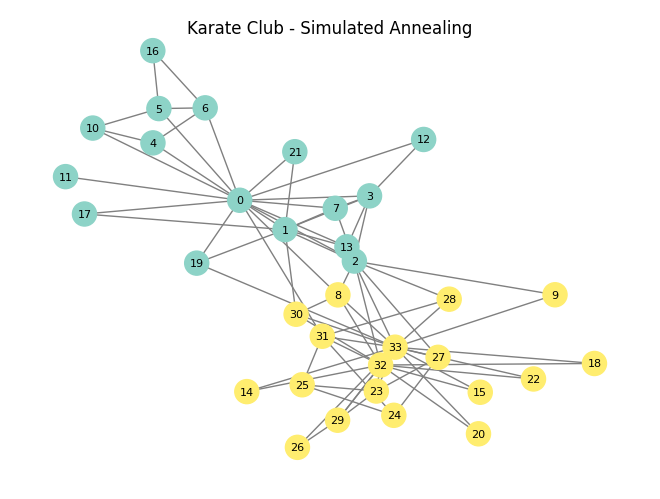

In [24]:
G1 = nx.karate_club_graph()
network1 = Network(G1, resolution=1.0)

problem1 = CommunityDetectionProblem(network1, communities=2, one_hot_encoding=False)
solver1 = SimulatedAnnealingSolver(problem1, Tmax=25000, Tmin=2.5, steps=30000, updates=0)
result1 = solver1.solve()

sa_communities1 = extract_communities(result1, problem1)
sa_modularity1 = calculate_modularity_nx(G1, sa_communities1, resolution=1.0)

print("Karate Club Network")
print("=" * 70)
print(f"Nodes: {G1.number_of_nodes()}, Edges: {G1.number_of_edges()}")
print(f"\nSimulated Annealing:")
print(f"  Modularity: {sa_modularity1:.6f}")
print(f"  Communities: {len(set(sa_communities1.values()))}")

visualize_comparison(G1, sa_communities1, "Karate Club")

## Test 2: Dumbell

Random Graph 1 (20 nodes)
Nodes: 23, Edges: 94

Simulated Annealing:
  Modularity: 0.489305
  Communities: 2


C:\Users\Kacper\AppData\Local\Temp\ipykernel_2908\1168737632.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


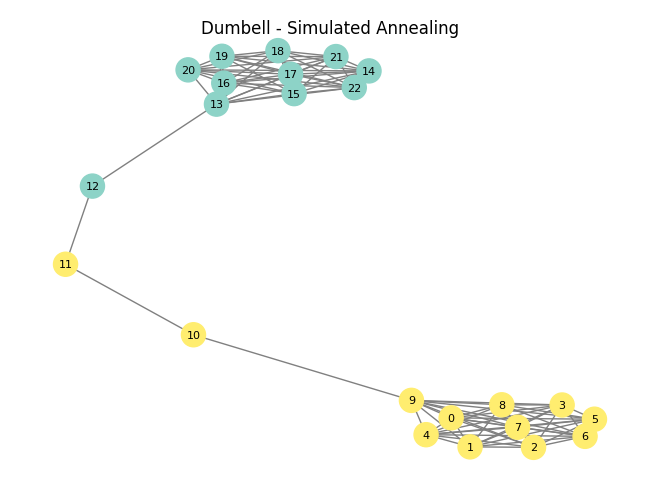

In [25]:
G2 = nx.barbell_graph(10, 3)
network2 = Network(G2, resolution=1.0)

problem2 = CommunityDetectionProblem(network2, one_hot_encoding=False)
solver2 = SimulatedAnnealingSolver(problem2, Tmax=200000, Tmin=2.0, steps=200000, updates=0)
result2 = solver2.solve()

sa_communities2 = extract_communities(result2, problem2)
sa_modularity2 = calculate_modularity_nx(G2, sa_communities2, resolution=1.0)

print("Random Graph 1 (20 nodes)")
print("=" * 70)
print(f"Nodes: {G2.number_of_nodes()}, Edges: {G2.number_of_edges()}")
print(f"\nSimulated Annealing:")
print(f"  Modularity: {sa_modularity2:.6f}")
print(f"  Communities: {len(set(sa_communities2.values()))}")

visualize_comparison(G2, sa_communities2, "Dumbell")

## Test 3: Caveman graph

 Temperature        Energy    Accept   Improve     Elapsed   Remaining
     2.50000       -333.64     0.57%     0.14%     0:00:25     0:00:00


Caveman Graph
Nodes: 50, Edges: 225

Simulated Annealing:
  Modularity: 0.777778
  Communities: 5


C:\Users\Kacper\AppData\Local\Temp\ipykernel_2908\1168737632.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


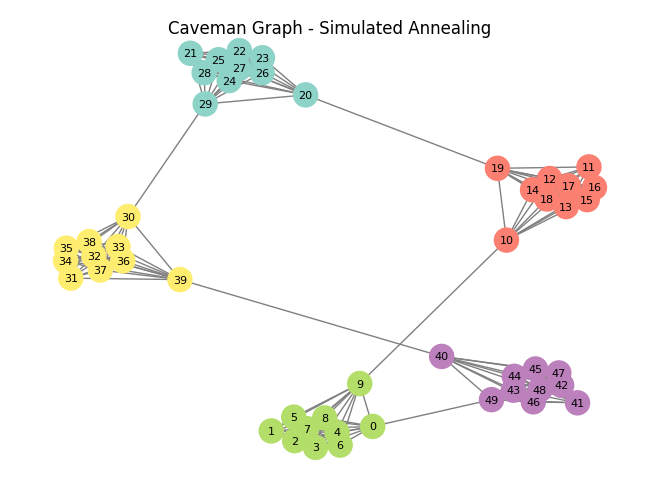

In [28]:
G3 = nx.connected_caveman_graph(5, 10)
network3 = Network(G3, resolution=1.0)

problem3 = CommunityDetectionProblem(network3, communities=5, one_hot_encoding=False)
solver3 = SimulatedAnnealingSolver(problem3, Tmax=70000, Tmin=2.5, steps=70000, updates=100)
result3 = solver3.solve()

sa_communities3 = extract_communities(result3, problem3)
sa_modularity3 = calculate_modularity_nx(G3, sa_communities3, resolution=1.0)

print("\nCaveman Graph")
print("=" * 70)
print(f"Nodes: {G3.number_of_nodes()}, Edges: {G3.number_of_edges()}")
print(f"\nSimulated Annealing:")
print(f"  Modularity: {sa_modularity3:.6f}")
print(f"  Communities: {len(set(sa_communities3.values()))}")

visualize_comparison(G3, sa_communities3, "Caveman Graph")